# HR Analytics — SQL, Python & Power BI

## Project Overview

This project analyzes employee workforce data to identify key HR trends and workforce patterns.

The analysis focuses on employee demographics, workforce status, departmental performance, employee tenure, hiring trends, and termination patterns.

The project combines **Python, SQL, and Power BI** to demonstrate an end-to-end HR analytics workflow.

In [17]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Get the project folder
BASE_DIR = os.getcwd()

# Results folder
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load dataset
df = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "dataset",
        "Human Resources.csv"
    )
)

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (22214, 13)

Columns:
['id', 'first_name', 'last_name', 'birthdate', 'gender', 'race', 'department', 'jobtitle', 'location', 'hire_date', 'termdate', 'location_city', 'location_state']


## 2. Data Cleaning

Before performing the analysis, the dataset is cleaned and prepared for analysis.

The following steps are performed:

- Convert employee date columns into proper datetime format.
- Remove unnecessary whitespace from text fields.
- Remove duplicate employee records.
- Prepare the dataset for workforce and demographic analysis.

In [18]:
# Convert date columns
df["birthdate"] = pd.to_datetime(
    df["birthdate"],
    errors="coerce"
)

df["hire_date"] = pd.to_datetime(
    df["hire_date"],
    errors="coerce"
)

df["termdate"] = pd.to_datetime(
    df["termdate"],
    errors="coerce"
)

# Clean text columns
text_columns = [
    "gender",
    "race",
    "department",
    "jobtitle",
    "location",
    "location_city",
    "location_state"
]

for column in text_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
    )

# Remove duplicate records
df = df.drop_duplicates()

print("Data cleaning completed.")
print("Cleaned Dataset Shape:", df.shape)

print("\nDate column types:")
print(df[["birthdate", "hire_date", "termdate"]].dtypes)

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_2204\1040528681.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["birthdate"] = pd.to_datetime(


Data cleaning completed.
Cleaned Dataset Shape: (22214, 13)

Date column types:
birthdate         datetime64[ns]
hire_date         datetime64[ns]
termdate     datetime64[ns, UTC]
dtype: object


## 3. Employee Status

Employee status is determined using the termination date.

- Employees without a termination date are classified as **Active**.
- Employees with a termination date are classified as **Terminated**.

This classification is used to calculate workforce and termination metrics.

In [19]:
# Create employee status
df["status"] = df["termdate"].isna().map({
    True: "Active",
    False: "Terminated"
})

print("Employee Status:")
print(df["status"].value_counts())

Employee Status:
status
Active        18285
Terminated     3929
Name: count, dtype: int64


## 4. Age and Tenure Analysis

Employee age and tenure are calculated to understand workforce demographics and employee experience.

- **Age** is calculated from the employee's birth date.
- **Tenure** is calculated from the hire date to the termination date.
- For active employees, the current date is used as the end date.

In [31]:
# ---------------------------------------
# Age and Tenure Analysis
# ---------------------------------------

# Convert date columns
df["birthdate"] = pd.to_datetime(
    df["birthdate"],
    errors="coerce"
)

df["hire_date"] = pd.to_datetime(
    df["hire_date"],
    errors="coerce"
)

df["termdate"] = pd.to_datetime(
    df["termdate"],
    errors="coerce"
)

today = pd.Timestamp.today()

# ---------------------------------------
# Calculate Age
# ---------------------------------------

def calculate_age(birthdate):
    if pd.isna(birthdate):
        return pd.NA

    age = today.year - birthdate.year

    if (today.month, today.day) < (
        birthdate.month,
        birthdate.day
    ):
        age -= 1

    return age


df["age"] = df["birthdate"].apply(calculate_age)

# ---------------------------------------
# Calculate Tenure
# ---------------------------------------

def calculate_tenure(row):
    hire_date = row["hire_date"]
    term_date = row["termdate"]

    if pd.isna(hire_date):
        return pd.NA

    if pd.isna(term_date):
        end_date = today
    else:
        end_date = term_date

    tenure = end_date.year - hire_date.year

    if (end_date.month, end_date.day) < (
        hire_date.month,
        hire_date.day
    ):
        tenure -= 1

    return tenure


df["tenure_years"] = df.apply(
    calculate_tenure,
    axis=1
)

print("Age and tenure calculations completed.")

print(
    f"Average Age: "
    f"{pd.to_numeric(df['age'], errors='coerce').mean():.1f} years"
)

print(
    f"Average Tenure: "
    f"{pd.to_numeric(df['tenure_years'], errors='coerce').mean():.1f} years"
)

Age and tenure calculations completed.
Average Age: 31.3 years
Average Tenure: 14.3 years


## 5. Workforce Metrics

Key workforce KPIs are calculated to provide an overall view of the employee population.

The metrics include:

- Total employees
- Active employees
- Terminated employees
- Overall termination rate
- Average employee age
- Average employee tenure

In [21]:
# Workforce metrics

total_employees = len(df)

active_employees = (
    df["status"] == "Active"
).sum()

terminated_employees = (
    df["status"] == "Terminated"
).sum()

termination_rate = (
    terminated_employees / total_employees
) * 100

print("HR WORKFORCE METRICS")
print("=" * 40)

print("Total Employees:", total_employees)
print("Active Employees:", active_employees)
print("Terminated Employees:", terminated_employees)
print(f"Termination Rate: {termination_rate:.2f}%")
print(f"Average Age: {df['age'].mean():.1f} years")
print(f"Average Tenure: {df['tenure_years'].mean():.1f} years")

HR WORKFORCE METRICS
Total Employees: 22214
Active Employees: 18285
Terminated Employees: 3929
Termination Rate: 17.69%
Average Age: 31.3 years
Average Tenure: 14.8 years


## 6. Department Analysis

Department-level analysis is used to understand workforce distribution and identify departments with higher employee termination rates.

Employees by Department:
department
Engineering                 6686
Accounting                  3333
Sales                       1832
Human Resources             1807
Training                    1692
Services                    1686
Business Development        1642
Research and Development    1084
Support                      954
Product Management           641
Marketing                    494
Legal                        311
Auditing                      52
Name: count, dtype: int64


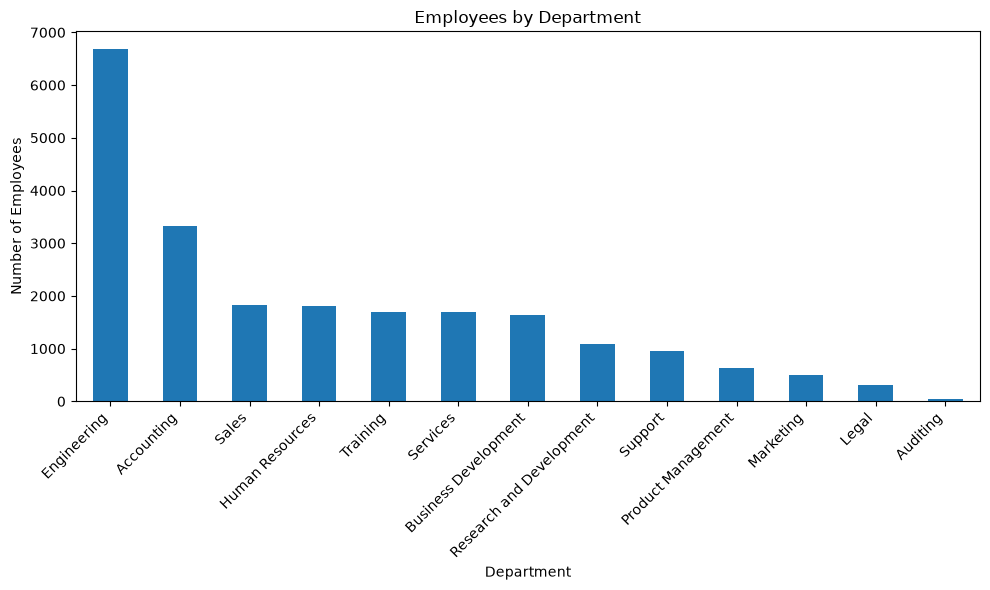


Termination Rate by Department:
department
Auditing                    23.076923
Legal                       20.257235
Research and Development    19.557196
Support                     19.077568
Sales                       18.286026
Product Management          17.784711
Engineering                 17.723602
Accounting                  17.581758
Services                    17.378410
Training                    17.198582
Human Resources             17.100166
Business Development        16.747868
Marketing                   14.574899
Name: status, dtype: float64


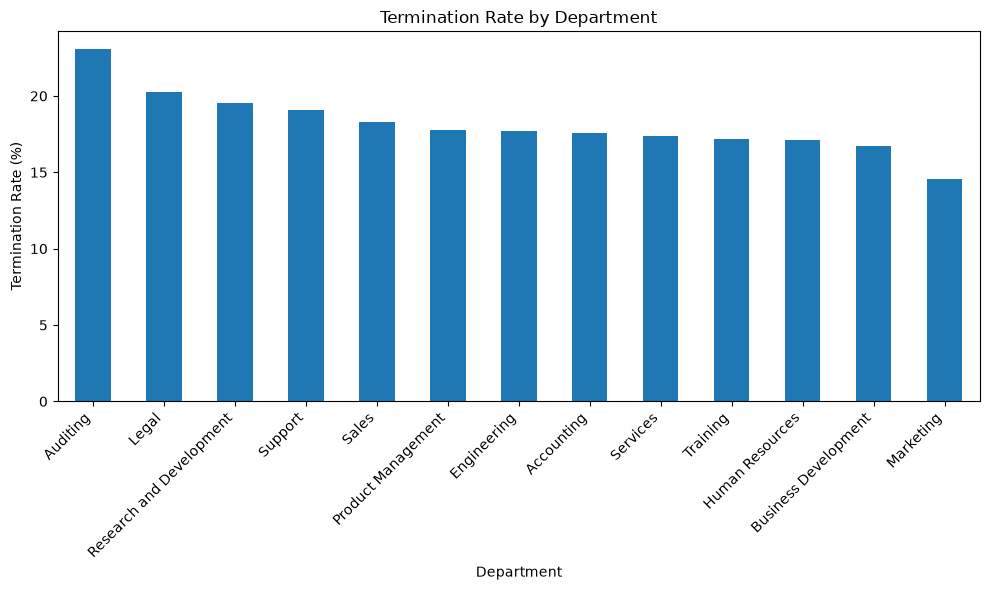

In [32]:
# ---------------------------------------
# Department Analysis
# ---------------------------------------

# Employee count by department
department_count = df["department"].value_counts()

print("Employees by Department:")
print(department_count)

plt.figure(figsize=(10, 6))

department_count.plot(kind="bar")

plt.title("Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()


# Termination rate by department
department_termination = (
    df.groupby("department")["status"]
    .apply(
        lambda x: (x == "Terminated").mean() * 100
    )
    .sort_values(ascending=False)
)

print("\nTermination Rate by Department:")
print(department_termination)

plt.figure(figsize=(10, 6))

department_termination.plot(kind="bar")

plt.title("Termination Rate by Department")
plt.xlabel("Department")
plt.ylabel("Termination Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## 7. Gender Analysis

Gender distribution is analyzed to understand the demographic composition of the workforce.

Termination rates are also compared across gender groups to identify differences in employee retention patterns.

Employees by Gender:
gender
Male              11288
Female            10321
Non-Conforming      605
Name: count, dtype: int64


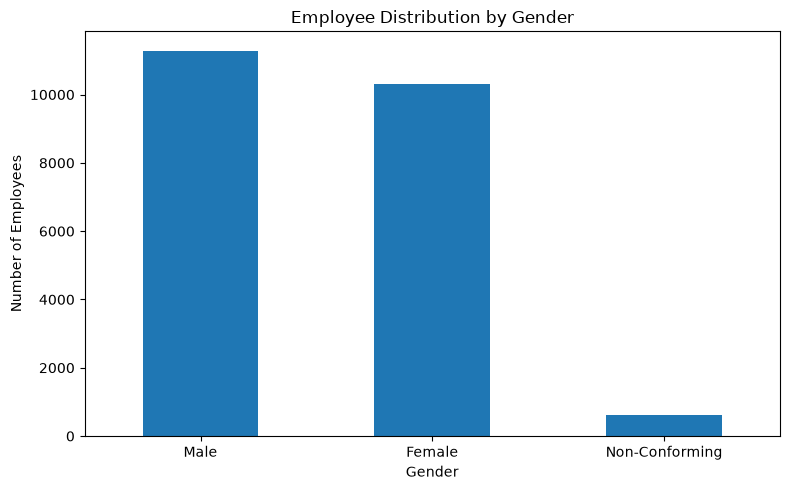


Termination Rate by Gender:
gender
Female            18.079643
Male              17.363572
Non-Conforming    17.024793
Name: status, dtype: float64


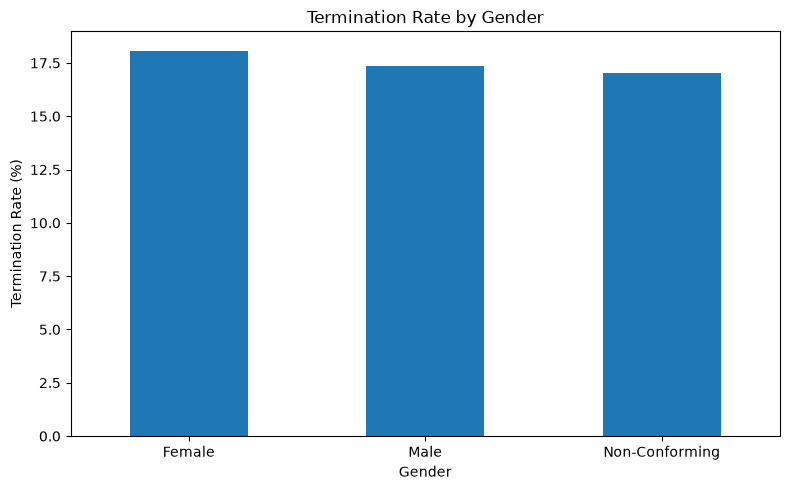

In [23]:
# Gender distribution

gender_count = df["gender"].value_counts()

print("Employees by Gender:")
print(gender_count)

plt.figure(figsize=(8, 5))

gender_count.plot(kind="bar")

plt.title("Employee Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()


# Termination rate by gender

gender_termination = (
    df.groupby("gender")["status"]
    .apply(
        lambda x: (x == "Terminated").mean() * 100
    )
    .sort_values(ascending=False)
)

print("\nTermination Rate by Gender:")
print(gender_termination)

plt.figure(figsize=(8, 5))

gender_termination.plot(kind="bar")

plt.title("Termination Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Termination Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## 8. Age Distribution

The age distribution shows the composition of the workforce across different age groups and helps identify the predominant employee age ranges.

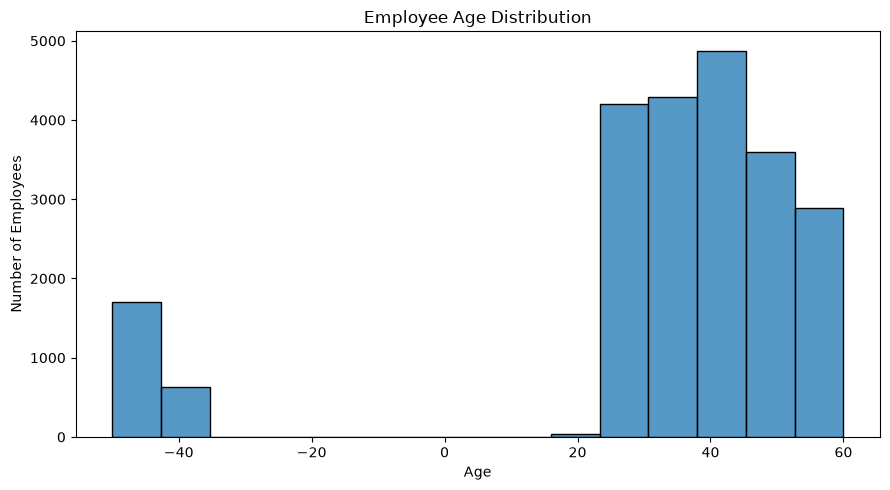

In [24]:
# Employee age distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="age",
    bins=15
)

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.tight_layout()

plt.show()

## 9. Job Title Analysis

Job-title analysis identifies the roles with the highest number of employees and helps understand workforce concentration across positions.

Top 15 Job Titles:
jobtitle
Project Manager                         340
Business Systems Development Analyst    341
Data Coordiator                         356
Senior Developer                        361
Analyst Programmer                      372
Systems Administrator I                 374
Software Engineer I                     397
Human Resources Analyst                 408
Staff Accountant I                      441
Data Visualization Specialist           457
Account Executive                       505
Research Assistant I                    538
Human Resources Analyst II              613
Business Analyst                        708
Research Assistant II                   754
Name: count, dtype: int64


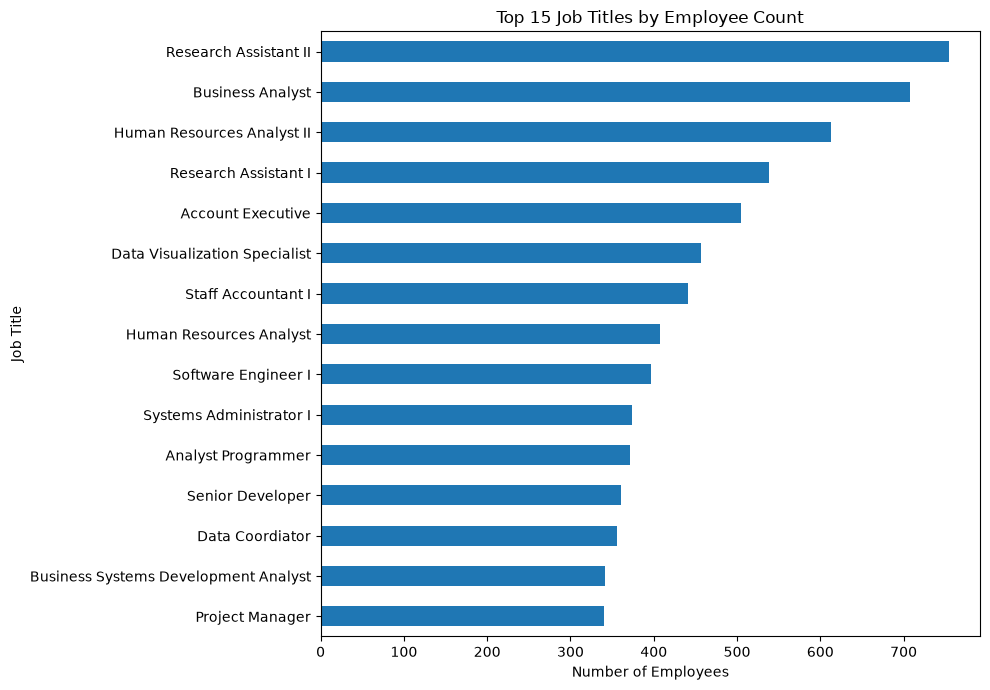

In [25]:
# Top 15 job titles

job_title_count = (
    df["jobtitle"]
    .value_counts()
    .head(15)
    .sort_values()
)

print("Top 15 Job Titles:")
print(job_title_count)

plt.figure(figsize=(10, 7))

job_title_count.plot(kind="barh")

plt.title("Top 15 Job Titles by Employee Count")
plt.xlabel("Number of Employees")
plt.ylabel("Job Title")
plt.tight_layout()

plt.show()

## 10. Hiring and Termination Trends

Yearly hiring and termination trends are analyzed to understand how the organization's workforce has changed over time.

This analysis helps identify periods of increased hiring and employee departures.

Employees Hired by Year:
hire_date
2000.0    149
2001.0    688
2002.0    642
2003.0    683
2004.0    683
2005.0    677
2006.0    668
2007.0    653
2008.0    675
2009.0    663
2010.0    668
2011.0    681
2012.0    692
2013.0    658
2014.0    620
2015.0    655
2016.0    691
2017.0    685
2018.0    724
2019.0    652
2020.0    590
Name: count, dtype: int64


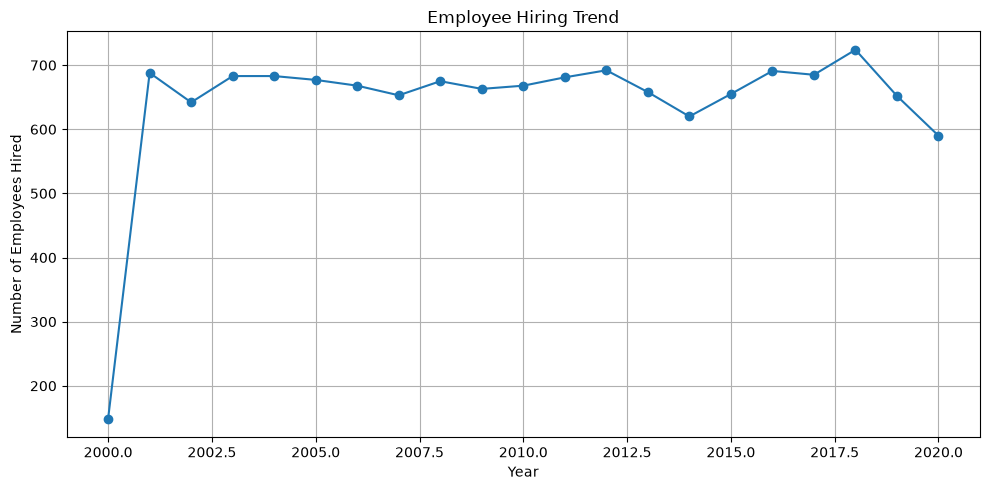

In [26]:
# Hiring trend by year

hire_year = (
    df["hire_date"]
    .dt.year
    .value_counts()
    .sort_index()
)

print("Employees Hired by Year:")
print(hire_year)

plt.figure(figsize=(10, 5))

hire_year.plot(
    kind="line",
    marker="o"
)

plt.title("Employee Hiring Trend")
plt.xlabel("Year")
plt.ylabel("Number of Employees Hired")
plt.grid(True)
plt.tight_layout()

plt.show()

Terminations by Year:
termdate
2001      7
2002     10
2003     31
2004     29
2005     50
2006     68
2007     50
2008     87
2009     74
2010    116
2011     89
2012    124
2013    112
2014    116
2015    131
2016    142
2017    153
2018    166
2019    177
2020    166
2021    205
2022    186
2023    163
2024    178
2025    160
2026    143
2027    116
2028    101
2029    108
2030     99
2031    102
2032     90
2033     89
2034     68
2035     75
2036     48
2037     43
2038     33
2039     13
2040      8
2041      3
Name: count, dtype: int64


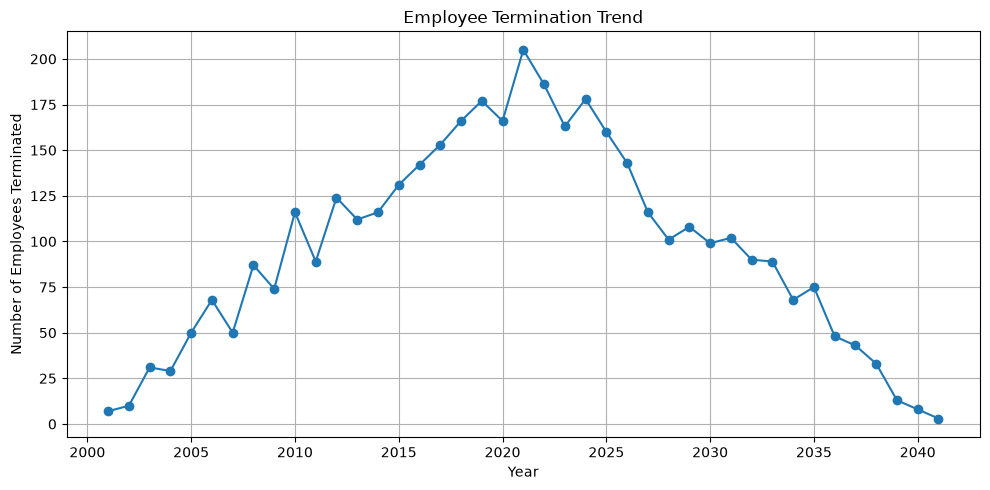

In [27]:
# Termination trend by year

termination_year = (
    df.loc[
        df["status"] == "Terminated",
        "termdate"
    ]
    .dt.year
    .value_counts()
    .sort_index()
)

print("Terminations by Year:")
print(termination_year)

plt.figure(figsize=(10, 5))

termination_year.plot(
    kind="line",
    marker="o"
)

plt.title("Employee Termination Trend")
plt.xlabel("Year")
plt.ylabel("Number of Employees Terminated")
plt.grid(True)
plt.tight_layout()

plt.show()

## 11. Key HR Findings

The analysis provides insights into workforce size, employee status, demographics, departmental composition, employee tenure, hiring activity, and termination patterns.

The key findings are summarized using the calculated workforce metrics and analysis results.

In [28]:
# Key HR findings

print("KEY HR FINDINGS")
print("=" * 40)

print(f"Total Employees: {total_employees}")
print(f"Active Employees: {active_employees}")
print(f"Terminated Employees: {terminated_employees}")
print(f"Overall Termination Rate: {termination_rate:.2f}%")

print(
    f"Average Employee Age: "
    f"{df['age'].mean():.1f} years"
)

print(
    f"Average Employee Tenure: "
    f"{df['tenure_years'].mean():.1f} years"
)

print("\nDepartment with Highest Termination Rate:")
print(department_termination.index[0])
print(
    f"Rate: "
    f"{department_termination.iloc[0]:.2f}%"
)

print("\nMost Common Job Title:")
print(df["jobtitle"].value_counts().index[0])

KEY HR FINDINGS
Total Employees: 22214
Active Employees: 18285
Terminated Employees: 3929
Overall Termination Rate: 17.69%
Average Employee Age: 31.3 years
Average Employee Tenure: 14.8 years

Department with Highest Termination Rate:
Auditing
Rate: 23.08%

Most Common Job Title:
Research Assistant II


## 12. Conclusion

This project demonstrates an end-to-end HR analytics workflow using Python, SQL, and Power BI.

Python was used for data cleaning, transformation, exploratory analysis, KPI calculation, and visualization. SQL was used for structured HR data analysis, while Power BI was used to present the results through an interactive dashboard.

The analysis provides insights into employee demographics, workforce status, departmental termination rates, hiring trends, termination trends, job-title distribution, and employee tenure.

These insights can support HR teams in understanding workforce patterns and making data-driven workforce planning and retention decisions.

In [29]:
# Save cleaned dataset

output_path = os.path.join(
    RESULTS_DIR,
    "cleaned_hr_data.csv"
)

df.to_csv(
    output_path,
    index=False
)

print("Cleaned HR dataset saved successfully.")
print(output_path)

Cleaned HR dataset saved successfully.
c:\Users\ELCOT\Downloads\HR-Analytics-with-SQL-and-Power-BI-main\HR-Analytics-with-SQL-and-Power-BI-main\results\cleaned_hr_data.csv
